In [1]:
import numpy as np
import glob
import json
import h5py

import matplotlib.pyplot as plt
import scipy.stats as sps

In [2]:
def harvest(fbase, prefix, num_sims_per_file, f_param_config, out_name, save_on=True):
    """
    Collate .npy sim files into one HDF5 and extract a prior JSON.

    HDF5 layout
    -----------
    attrs['param_names'] : list of str, canonical param ordering
    events/cs1           : (total_events,)  all sims concatenated
    events/cs2           : (total_events,)  all sims concatenated
    events/n_events      : (n_sims,)        events per sim
    params/<name>        : (n_sims,)        one dataset per floated param

    To load sim i: split cs1/cs2 on cumsum(n_events), index with i.
    To load first N sims: slice n_events[:N], cs1[:n_events[:N].sum()], params/<name>[:N].
    """
    fnames = sorted(glob.glob(f'{fbase}/{prefix}_{num_sims_per_file:.0f}sims*.npy'))
    print(f'Found {len(fnames)} files.')

    bag = np.load(fnames[0], allow_pickle=True).item()
    for _f in fnames[1:]:
        tmp = np.load(_f, allow_pickle=True).item()
        for k in bag.keys():
            bag[k].extend(tmp[k])

    n_total = num_sims_per_file * len(fnames)
    assert len(bag['events_bag']) == n_total, (
        f'Expected {n_total} sims, got {len(bag["events_bag"])}')
    print(f'{n_total} sims loaded.')

    param_names = list(bag['param_bag'][0].keys())
    print(f'Floated params: {param_names}')

    h5_path   = f'{fbase}/{out_name}.h5'
    json_path = f'{fbase}/prior_{out_name}.json'

    # --- HDF5 ---
    if save_on:
        cs1      = np.concatenate([e[0] for e in bag['events_bag']])
        cs2      = np.concatenate([e[1] for e in bag['events_bag']])
        n_events = np.array([e.shape[1] for e in bag['events_bag']], dtype=np.int32)
        params   = {par: np.array([p[par] for p in bag['param_bag']]) for par in param_names}

        with h5py.File(h5_path, 'w') as f:
            f.attrs['param_names'] = param_names
            eg = f.create_group('events')
            eg.create_dataset('cs1',      data=cs1,      compression='gzip')
            eg.create_dataset('cs2',      data=cs2,      compression='gzip')
            eg.create_dataset('n_events', data=n_events, compression='gzip')
            pg = f.create_group('params')
            for par in param_names:
                pg.create_dataset(par, data=params[par], compression='gzip')
        print(f'Saved: {h5_path}')

    # --- Prior JSON ---
    with open(f_param_config) as fid:
        param_config = json.load(fid)

    prior_config = {}
    for par in param_names:
        cfg = param_config[par]
        prior_type = cfg['prior_type']
        if prior_type == 'uniform':
            prior_args = cfg['prior_args']
        elif prior_type == 'norm':
            prior_args = cfg['prior_args']
        elif prior_type == 'free':
            prior_args = {'mean': cfg['init_mean'], 'std': cfg['init_std']}
            prior_type = 'norm'
        else:
            raise ValueError(f"Unknown prior_type '{prior_type}' for param '{par}'")
        prior_config[par] = {
            'prior_type':    prior_type,
            'prior_args':    prior_args,
            'allowed_range': cfg['allowed_range'],
        }

    print(f'Prior config:\n{json.dumps(prior_config, indent=4)}')
    if save_on:
        with open(json_path, 'w') as fid:
            json.dump(prior_config, fid, indent=4)
        print(f'Saved: {json_path}')

    return bag, prior_config

In [3]:
# ===== TRAINING SET — uniform g1 (proposal prior) =====
# 10x20k sims, uniform g1 [0.12, 0.14]
bag_train_ug1, prior_train_ug1 = harvest(
    fbase='/home/puehlengt/appletree/notebooks/1_param/training_set/uniformg1',
    prefix='testsims_1param_uniformg1',
    num_sims_per_file=20000,
    f_param_config='/home/puehlengt/appletree/notebooks/param_nr_sr1_1param_uniformg1.json',
    out_name='harvested_training_uniformg1',
    save_on=True,
)

Found 10 files.
200000 sims loaded.
Floated params: ['g1']
Saved: /home/puehlengt/appletree/notebooks/1_param/training_set/uniformg1/harvested_training_uniformg1.h5
Prior config:
{
    "g1": {
        "prior_type": "uniform",
        "prior_args": {
            "lower": 0.132,
            "upper": 0.142
        },
        "allowed_range": [
            0,
            1.0
        ]
    }
}
Saved: /home/puehlengt/appletree/notebooks/1_param/training_set/uniformg1/prior_harvested_training_uniformg1.json


In [4]:
# ===== TRAINING SET — norm g1 (inference prior) =====
# 10x20k sims, tight Gaussian g1
bag_train_ng1, prior_train_ng1 = harvest(
    fbase='/home/puehlengt/appletree/notebooks/1_param/training_set/normg1',
    prefix='testsims_1param_normg1',
    num_sims_per_file=20000,
    f_param_config='/home/puehlengt/appletree/notebooks/param_nr_sr1_1param_normg1.json',
    out_name='harvested_training_normg1',
    save_on=True,
)

Found 10 files.
200000 sims loaded.
Floated params: ['g1']
Saved: /home/puehlengt/appletree/notebooks/1_param/training_set/normg1/harvested_training_normg1.h5
Prior config:
{
    "g1": {
        "prior_type": "norm",
        "prior_args": {
            "mean": 0.1367,
            "std": 0.001
        },
        "allowed_range": [
            0,
            1.0
        ]
    }
}
Saved: /home/puehlengt/appletree/notebooks/1_param/training_set/normg1/prior_harvested_training_normg1.json


In [5]:
# ===== TEST SET — norm g1 (inference prior) =====
# 10x200 sims, tight Gaussian g1
bag_test, prior_test = harvest(
    fbase='/home/puehlengt/appletree/notebooks/1_param/test_set',
    prefix='testsims_1param_normg1_testset',
    num_sims_per_file=200,
    f_param_config='/home/puehlengt/appletree/notebooks/param_nr_sr1_1param_normg1.json',
    out_name='harvested_testing_normg1',
    save_on=True,
)

Found 10 files.
2000 sims loaded.
Floated params: ['g1']
Saved: /home/puehlengt/appletree/notebooks/1_param/test_set/harvested_testing_normg1.h5
Prior config:
{
    "g1": {
        "prior_type": "norm",
        "prior_args": {
            "mean": 0.1367,
            "std": 0.001
        },
        "allowed_range": [
            0,
            1.0
        ]
    }
}
Saved: /home/puehlengt/appletree/notebooks/1_param/test_set/prior_harvested_testing_normg1.json


In [ ]:
raise

In [6]:
def plot_param_histograms(h5_path, prior_json_path, title):
    with h5py.File(h5_path, 'r') as f:
        param_names = [p.decode() if isinstance(p, bytes) else p
                       for p in f.attrs['param_names']]
        samples = {par: f['params'][par][:] for par in param_names}

    with open(prior_json_path) as fid:
        prior_cfg = json.load(fid)

    n_params = len(param_names)
    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 4))
    if n_params == 1:
        axes = [axes]

    for ax, par in zip(axes, param_names):
        vals = samples[par]
        ax.hist(vals, bins=50, density=True, histtype='step', color='steelblue', label='samples')

        spec       = prior_cfg[par]
        prior_type = spec['prior_type']
        args       = spec['prior_args']
        x          = np.linspace(vals.min(), vals.max(), 500)

        if prior_type == 'norm':
            pdf = sps.norm.pdf(x, loc=args['mean'], scale=args['std'])
            label = f"N({args['mean']}, {args['std']})"
        elif prior_type == 'uniform':
            width = args['upper'] - args['lower']
            pdf   = sps.uniform.pdf(x, loc=args['lower'], scale=width)
            label = f"U({args['lower']}, {args['upper']})"

        ax.plot(x, pdf, color='orange', lw=2, label=label)
        ax.set_xlabel(par)
        ax.set_ylabel('PDF')
        ax.legend(fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

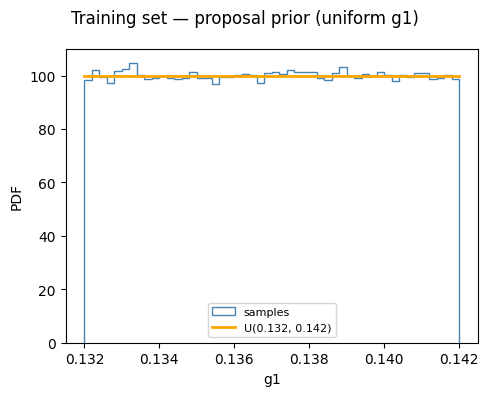

In [7]:
plot_param_histograms(
    h5_path='/home/puehlengt/appletree/notebooks/1_param/training_set/uniformg1/harvested_training_uniformg1.h5',
    prior_json_path='/home/puehlengt/appletree/notebooks/1_param/training_set/uniformg1/prior_harvested_training_uniformg1.json',
    title='Training set — proposal prior (uniform g1)',
)

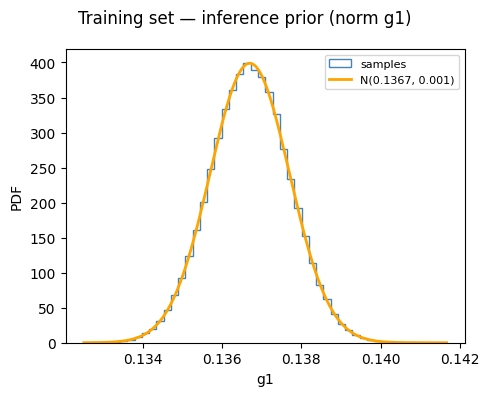

In [8]:
plot_param_histograms(
    h5_path='/home/puehlengt/appletree/notebooks/1_param/training_set/normg1/harvested_training_normg1.h5',
    prior_json_path='/home/puehlengt/appletree/notebooks/1_param/training_set/normg1/prior_harvested_training_normg1.json',
    title='Training set — inference prior (norm g1)',
)

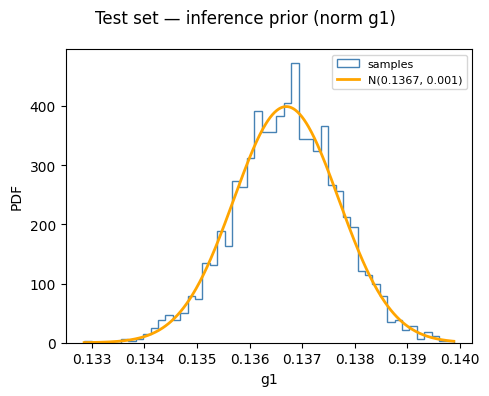

In [11]:
plot_param_histograms(
    h5_path='/home/puehlengt/appletree/notebooks/1_param/test_set/harvested_testing_normg1.h5',
    prior_json_path='/home/puehlengt/appletree/notebooks/1_param/test_set/prior_harvested_testing_normg1.json',
    title='Test set — inference prior (norm g1)',
)